In [ ]:
import gdown
import zipfile
import os

# 
gdown.download(
    'https://drive.google.com/file/d/1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ/view',
    '/content/dataset.zip',
    quiet=False,
    fuzzy=True
)

# 
size = os.path.getsize('/content/dataset.zip')
print(f"Downloaded file size: {size / (1024*1024):.2f} MB")


with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

DATA_DIR = '/content/dataset'
print("Done! Folders:", os.listdir(DATA_DIR))

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=f7d10be3-0138-432e-bcdd-aeae4f678555
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:09<00:00, 121MB/s] 


Downloaded file size: 1075.06 MB
Done! Folders: ['dataset', '__MACOSX']


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

In [ ]:
TRAIN_DIR   = '/content/dataset/dataset/train'
VAL_DIR     = '/content/dataset/dataset/val'

IMG_SIZE    = (150, 150)   
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 3
CLASS_NAMES = ['no', 'sphere', 'vort']

print("Train folders:", os.listdir(TRAIN_DIR))
print("Val folders:",   os.listdir(VAL_DIR))

Train folders: ['no', 'sphere', '.DS_Store', 'vort']
Val folders: ['no', 'sphere', '.DS_Store', 'vort']


In [ ]:
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence

class NpyDataGenerator(Sequence):
    def __init__(self, data_dir, class_names, img_size, batch_size, augment=False):
        self.img_size    = img_size
        self.class_names = class_names
        self.batch_size  = batch_size
        self.augment     = augment

        self.filepaths = []
        self.labels    = []

        for label_idx, class_name in enumerate(class_names):
            class_path = os.path.join(data_dir, class_name)
            files = [f for f in os.listdir(class_path) if f.endswith('.npy')]
            for fname in files:
                self.filepaths.append(os.path.join(class_path, fname))
                self.labels.append(label_idx)

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        np.random.shuffle(self.indices)

        print(f"Generator ready: {len(self.filepaths)} files, {len(class_names)} classes")

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx    = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths  = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]

        X, y = [], []
        for path, label in zip(batch_paths, batch_labels):
            img = np.load(path).astype(np.float32)  # shape: (1, 150, 150)
            img = np.squeeze(img, axis=0)            # (150, 150)
            img = np.expand_dims(img, axis=-1)       # (150, 150, 1)

            # Simple augmentation
            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            X.append(img)
            y.append(label)

        return np.array(X), to_categorical(np.array(y), num_classes=len(self.class_names))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)  # Reshuffle each epoch


# Creating generators
train_gen = NpyDataGenerator(TRAIN_DIR, CLASS_NAMES, IMG_SIZE, BATCH_SIZE, augment=True)
val_gen   = NpyDataGenerator(VAL_DIR,   CLASS_NAMES, IMG_SIZE, BATCH_SIZE, augment=False)

# Checking one batch shape
X_batch, y_batch = train_gen[0]
print(f"Batch X shape: {X_batch.shape}")   # Should be (32, 150, 150, 1)
print(f"Batch y shape: {y_batch.shape}")   # Should be (32, 3)
print(f"Pixel range: {X_batch.min():.3f} to {X_batch.max():.3f}")
print(f"Channels: {X_batch.shape[-1]}")    # Should be 1

Generator ready: 30000 files, 3 classes
Generator ready: 7500 files, 3 classes
Batch X shape: (32, 150, 150, 1)
Batch y shape: (32, 3)
Pixel range: 0.000 to 1.000
Channels: 1


In [5]:
import numpy as np

sample_path = train_gen.filepaths[0]
sample = np.load(sample_path)

print("Raw .npy shape:", sample.shape)
print("dtype:", sample.dtype)
print("min:", sample.min(), "max:", sample.max())

Raw .npy shape: (1, 150, 150)
dtype: float64
min: 0.0 max: 1.0


In [ ]:
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence

#

class NpyDataGenerator(Sequence):
    def __init__(self, data_dir, class_names, img_size, batch_size, augment=False):
        self.img_size    = img_size
        self.class_names = class_names
        self.batch_size  = batch_size
        self.augment     = augment

        self.filepaths = []
        self.labels    = []

        for label_idx, class_name in enumerate(class_names):
            class_path = os.path.join(data_dir, class_name)
            files = [f for f in os.listdir(class_path) if f.endswith('.npy')]
            for fname in files:
                self.filepaths.append(os.path.join(class_path, fname))
                self.labels.append(label_idx)

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        np.random.shuffle(self.indices)

        print(f"Generator ready: {len(self.filepaths)} files, {len(class_names)} classes")

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx    = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths  = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]

        X, y = [], []
        for path, label in zip(batch_paths, batch_labels):
            img = np.load(path).astype(np.float32)  # shape: (1, 150, 150)
            img = np.squeeze(img, axis=0)            # (150, 150)
            img = np.expand_dims(img, axis=-1)       # (150, 150, 1)

            # Applying simple augmentation
            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            X.append(img)
            y.append(label)

        return np.array(X), to_categorical(np.array(y), num_classes=len(self.class_names))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)  # Reshuffle each epoch


# Creating generators
train_gen = NpyDataGenerator(TRAIN_DIR, CLASS_NAMES, IMG_SIZE, BATCH_SIZE, augment=True)
val_gen   = NpyDataGenerator(VAL_DIR,   CLASS_NAMES, IMG_SIZE, BATCH_SIZE, augment=False)

# Quick check
X_batch, y_batch = train_gen[0]
print(f"Batch X shape: {X_batch.shape} | y: {y_batch.shape}")
print(f"Pixel range: {X_batch.min():.3f} – {X_batch.max():.3f}")

Generator ready: 30000 files, 3 classes
Generator ready: 7500 files, 3 classes
Batch X shape: (32, 150, 150, 1) | y: (32, 3)
Pixel range: 0.000 – 1.000


In [ ]:
# 
from tensorflow.keras.applications import DenseNet201

def build_model():
    base = DenseNet201(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3),
        pooling=None
    )

    inputs = keras.Input(shape=(150, 150, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])  # grayscale -> fake RGB

    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Freezing most of base (fine-tune last ~30 layers)
    for layer in base.layers[:-30]:
        layer.trainable = False

    return model

model = build_model()
model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150, 150,  │          0 │ input_layer_2[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_2[0]… │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet201         │ (None, 4, 4,      │ 18,321,984 │ concatenate[0][0] │
│ (Functional)        │ 1920)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1920)      │          0 │ densenet201[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    983,552 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        771 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,439,683 (74.16 MB)

 Trainable params: 2,225,795 (8.49 MB)

 Non-trainable params: 17,213,888 (65.67 MB)

In [ ]:

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [ ]:

history = model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3975 - loss: 1.3007
Epoch 1: val_accuracy improved from None to 0.51787, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 224s 174ms/step - accuracy: 0.4242 - loss: 1.1777 - val_accuracy: 0.5179 - val_loss: 0.9920 - learning_rate: 5.0000e-04
Epoch 2/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4961 - loss: 1.0131
Epoch 2: val_accuracy improved from 0.51787 to 0.54040, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.5125 - loss: 0.9944 - val_accuracy: 0.5404 - val_loss: 0.9538 - learning_rate: 5.0000e-04
Epoch 3/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5435 - loss: 0.9577
Epoch 3: val_accuracy improved from 0.54040 to 0.56480, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 

Classification Report:
              precision    recall  f1-score   support

          no       0.76      0.87      0.81      2500
      sphere       0.68      0.62      0.65      2500
        vort       0.74      0.70      0.72      2500

    accuracy                           0.73      7500
   macro avg       0.73      0.73      0.73      7500
weighted avg       0.73      0.73      0.73      7500



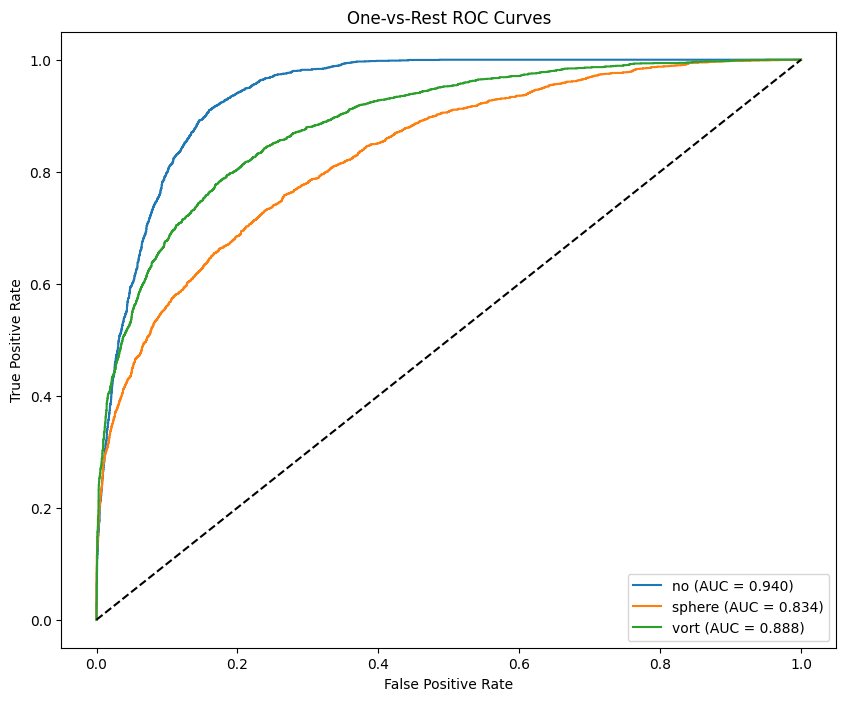

Final validation accuracy: 73.1%


In [ ]:
# 

y_true, y_pred, y_scores = [], [], []
for i in range(len(val_gen)):
    X, y = val_gen[i]
    preds = model.predict(X, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)
    y_true.extend(np.argmax(y, axis=1))

y_true = np.array(y_true)
y_scores = np.array(y_scores)

from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ROC curves
plt.figure(figsize=(10,8))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true == i, y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.show()

print(f"Final validation accuracy: {np.mean(y_true == y_pred):.1%}")